In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=713b61c9590ebe783b0d198031ae71ea44173eb0704f997340d62c33711db712
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

In [ ]:
spark = SparkSession \
    .builder \
    .appName("Spark_NLP") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Text Classification Using Word Embedding**

We can use n-gram model to capture the context of words with respect to their sequence of occurance. however, The resulting index size can be huge, especially for larger values of n, as it grows exponentially with the length of the sequence.

Embeddings are unique in terms of capturing the context of the words and representing them in such a way that words with similar meanings are represented with similar sort of embeddings.

**Reading the corpus**

In [ ]:
# Read CSV file into a DataFrame
#download the CSV file came along with this tutorial
#save in ggogle drive and change path according tou your dierectory structure
text_df= spark.read.csv('/content/drive/MyDrive/Files/Movie_reviews.csv',inferSchema=True, header =True)

In [ ]:
#check number of columns and their data type
text_df.printSchema()

root
 |-- Review: string (nullable = true)
 |-- Sentiment: string (nullable = true)



In [ ]:
# Show the first few rows of the DataFrame
text_df.show(10, False)

+------------------------------------------------------------------------+---------+
|Review                                                                  |Sentiment|
+------------------------------------------------------------------------+---------+
|The Da Vinci Code book is just awesome.                                 |1        |
|this was the first clive cussler i've ever read, but even books like Rel|1        |
|i liked the Da Vinci Code a lot.                                        |1        |
|i liked the Da Vinci Code a lot.                                        |1        |
|I liked the Da Vinci Code but it ultimatly didn't seem to hold it's own.|1        |
|that's not even an exaggeration ) and at midnight we went to Wal-Mart to|1        |
|I loved the Da Vinci Code, but now I want something better and different|1        |
|i thought da vinci code was great, same with kite runner.               |1        |
|The Da Vinci Code is actually a good movie...                   

In [ ]:
print((text_df.count(), len(text_df.columns)))

(7087, 2)


In [ ]:
text_df=text_df.filter(((text_df.Sentiment =='1') | (text_df.Sentiment =='0')))
text_df.count()

6990

In [ ]:
text_df.select('Sentiment').distinct().count()

2

In [ ]:
#We have no unlabeled tweets in the dataset. The next step is to validate the number of reviews for each class:
text_df.groupBy('Sentiment').count().show()

+---------+-----+
|Sentiment|count|
+---------+-----+
|        0| 3081|
|        1| 3909|
+---------+-----+



In [ ]:
text_df=text_df.withColumn("Label",text_df.Sentiment.cast('float')).drop('Sentiment')
from pyspark.sql.functions import rand
text_df.orderBy(rand()).show(10,False)

+------------------------------------------------------------------------+-----+
|Review                                                                  |Label|
+------------------------------------------------------------------------+-----+
|is he awesome in mission impossible 3 -- and hot.                       |1.0  |
|I love Harry Potter, Twilight, Series of Unfortunate Events, and tons mo|1.0  |
|friday hung out with kelsie and we went and saw The Da Vinci Code SUCKED|0.0  |
|Then snuck into Brokeback Mountain, which is the most depressing movie I|0.0  |
|Combining the opinion / review from Gary and Gin Zen, The Da Vinci Code |0.0  |
|DA VINCI CODE IS AWESOME!!                                              |1.0  |
|friday hung out with kelsie and we went and saw The Da Vinci Code SUCKED|0.0  |
|Derek and I saw 3 movies, Brokeback Mountain, which was beautiful, I alm|1.0  |
|Oh, and Brokeback Mountain was a terrible movie.                        |0.0  |
|I like MISSION IMPOSSIBLE b

In [ ]:
from pyspark.sql.functions import length
from pyspark.sql.functions import rand
text_df=text_df.withColumn('length',length(text_df['Review']))
text_df.orderBy(rand()).show(10,False)

+------------------------------------------------------------------------+-----+------+
|Review                                                                  |Label|length|
+------------------------------------------------------------------------+-----+------+
|da vinci code sucks...                                                  |0.0  |22    |
|I hate Harry Potter, that daniel wotshisface needs a fucking slap...    |0.0  |68    |
|Mission Impossible 3 was excellent.                                     |1.0  |35    |
|man i loved brokeback mountain!                                         |1.0  |31    |
|Harry Potter dragged Draco Malfoy ’ s trousers down past his hips and   |0.0  |69    |
|I love Harry Potter.                                                    |1.0  |20    |
|I love The Da Vinci Code...                                             |1.0  |27    |
|So Brokeback Mountain was really depressing.                            |0.0  |44    |
|He's like,'YEAH I GOT ACNE AND 

In [ ]:
text_df.groupBy('Label').agg({'Length':'mean'}).show()

+-----+-----------------+
|Label|      avg(Length)|
+-----+-----------------+
|  1.0|47.61882834484523|
|  0.0|50.95845504706264|
+-----+-----------------+



In [ ]:
from pyspark.ml.feature import Tokenizer
tokenization=Tokenizer(inputCol='Review',outputCol='tokens')
tokenized_df=tokenization.transform(text_df)
tokenized_df.show(10, False)

+------------------------------------------------------------------------+-----+------+----------------------------------------------------------------------------------------+
|Review                                                                  |Label|length|tokens                                                                                  |
+------------------------------------------------------------------------+-----+------+----------------------------------------------------------------------------------------+
|The Da Vinci Code book is just awesome.                                 |1.0  |39    |[the, da, vinci, code, book, is, just, awesome.]                                        |
|this was the first clive cussler i've ever read, but even books like Rel|1.0  |72    |[this, was, the, first, clive, cussler, i've, ever, read,, but, even, books, like, rel] |
|i liked the Da Vinci Code a lot.                                        |1.0  |32    |[i, liked, the, da, vinci, c

In [ ]:
 #OR use RegexTokenizer to only keep the words and remove the special characters such as ')',etc
 # Remove hashtags and special characters from the review column
 from pyspark.ml.feature import RegexTokenizer
 tokenization=RegexTokenizer(inputCol= 'Review' , outputCol= 'tokens', pattern= '\\W')
 tokenized_df=tokenization.transform(text_df)
tokenized_df.show(10, False)

+------------------------------------------------------------------------+-----+------+-----------------------------------------------------------------------------------------+
|Review                                                                  |Label|length|tokens                                                                                   |
+------------------------------------------------------------------------+-----+------+-----------------------------------------------------------------------------------------+
|The Da Vinci Code book is just awesome.                                 |1.0  |39    |[the, da, vinci, code, book, is, just, awesome]                                          |
|this was the first clive cussler i've ever read, but even books like Rel|1.0  |72    |[this, was, the, first, clive, cussler, i, ve, ever, read, but, even, books, like, rel]  |
|i liked the Da Vinci Code a lot.                                        |1.0  |32    |[i, liked, the, da, vin

In [ ]:
#Stop word removal
from pyspark.ml.feature import StopWordsRemover
stopword_removal=StopWordsRemover(inputCol='tokens',outputCol='refined_tokens')
refined_text_df=stopword_removal.transform(tokenized_df)
refined_text_df.show(10, False)
#note the difeerence between tokens and refined_tokens to understand how stop word removal works

+------------------------------------------------------------------------+-----+------+-----------------------------------------------------------------------------------------+---------------------------------------------------------------+
|Review                                                                  |Label|length|tokens                                                                                   |refined_tokens                                                 |
+------------------------------------------------------------------------+-----+------+-----------------------------------------------------------------------------------------+---------------------------------------------------------------+
|The Da Vinci Code book is just awesome.                                 |1.0  |39    |[the, da, vinci, code, book, is, just, awesome]                                          |[da, vinci, code, book, awesome]                               |
|this was the first clive cussle

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import *

In [ ]:
len_udf = udf(lambda s: len(s), IntegerType())
#This is a user defined function (udf), the lambda function takes a single argument s,
#which is a string. It calculates the length of the string s using the built-in len() function
#return an integer value for length of the string.
refined_text_df = refined_text_df.withColumn("token_count", len_udf(col('refined_tokens')))

In [ ]:
refined_text_df.orderBy(rand()).show(10)

+--------------------+-----+------+--------------------+--------------------+-----------+
|              Review|Label|length|              tokens|      refined_tokens|token_count|
+--------------------+-----+------+--------------------+--------------------+-----------+
|I love Harry Pott...|  1.0|    21|[i, love, harry, ...|[love, harry, pot...|          3|
|I think I hate Ha...|  0.0|    72|[i, think, i, hat...|[think, hate, har...|          9|
|My dad's being st...|  0.0|    49|[my, dad, s, bein...|[dad, stupid, bro...|          4|
|shit, i love the ...|  1.0|    31|[shit, i, love, t...|[shit, love, da, ...|          5|
| Harry Potter sucks.|  0.0|    19|[harry, potter, s...|[harry, potter, s...|          3|
|Oh, and Brokeback...|  0.0|    48|[oh, and, brokeba...|[oh, brokeback, m...|          5|
|MISSION IMPOSSIBL...|  1.0|    33|[mission, impossi...|[mission, impossi...|          4|
|I hate Harry Potter.|  0.0|    20|[i, hate, harry, ...|[hate, harry, pot...|          3|
|the last 

**N-Gram Model**

In [ ]:
from pyspark.ml.feature import NGram

ngram = NGram(n=2, inputCol="refined_tokens", outputCol="ngrams")

refined_text_df = ngram.transform(refined_text_df)
refined_text_df.select("refined_tokens","ngrams").show(truncate=False)

+---------------------------------------------------------------+---------------------------------------------------------------------------------------------------------+
|refined_tokens                                                 |ngrams                                                                                                   |
+---------------------------------------------------------------+---------------------------------------------------------------------------------------------------------+
|[da, vinci, code, book, awesome]                               |[da vinci, vinci code, code book, book awesome]                                                          |
|[first, clive, cussler, ve, ever, read, even, books, like, rel]|[first clive, clive cussler, cussler ve, ve ever, ever read, read even, even books, books like, like rel]|
|[liked, da, vinci, code, lot]                                  |[liked da, da vinci, vinci code, code lot]                                 

In [ ]:
from pyspark.ml.feature import CountVectorizer
count_vec=CountVectorizer(inputCol='ngrams',outputCol='features')
cv_text_df=count_vec.fit(refined_text_df).transform(refined_text_df)
cv_text_df.select(['refined_tokens','ngrams','features','Label']).show(20, False)

+---------------------------------------------------------------+---------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------+-----+
|refined_tokens                                                 |ngrams                                                                                                   |features                                                                                 |Label|
+---------------------------------------------------------------+---------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------+-----+
|[da, vinci, code, book, awesome]                               |[da vinci, vinci code, code book, book awesome]                                                          |(3386,[0,1,509,1303],[1.0

In [ ]:
vocabulary=count_vec.fit(refined_text_df).vocabulary
vocabulary

['da vinci',
 'vinci code',
 'brokeback mountain',
 'harry potter',
 'mission impossible',
 'hate harry',
 'love harry',
 'love brokeback',
 'code awesome',
 'code sucked',
 'code sucks',
 'love da',
 'impossible 3',
 'loved brokeback',
 'mountain awesome',
 'awesome movie',
 'mountain terrible',
 'terrible movie',
 'oh brokeback',
 'left right',
 '3 awesome',
 'mountain beautiful',
 'potter sucks',
 'like harry',
 'impossible 2',
 'mountain depressing',
 'heard da',
 'impossible movies',
 'first mission',
 'like mission',
 'potter series',
 'stupid brokeback',
 'much love',
 'mountain horrible',
 'saw da',
 'depressing movie',
 'sucked big',
 'potter suck',
 'mountain really',
 'potter awesome',
 'horrible movie',
 'potter movies',
 'reading harry',
 'big time',
 'went saw',
 'way da',
 'think hate',
 'like things',
 'mountain think',
 'really depressing',
 'potter type',
 'absolutely awesome',
 'impossible tom',
 'care anyone',
 'much better',
 'mountain boring',
 'watch mission',
 '

**Word2Vec for feature representation**

In [ ]:
# Word2Vec model
from pyspark.ml.feature import Word2Vec
word2vec = Word2Vec(vectorSize=100, minCount=2, inputCol="refined_tokens", outputCol="features")

#each word will be represented as a dense vector of 100 dimensions.
#minCount=5 denotes minimum frequency a word must have to be included in the Word2Vec model.
#Words that occur fewer than 5 times in the corpus will be ignored.
word2vec_model = word2vec.fit(refined_text_df)
vectorized_data = word2vec_model.transform(refined_text_df)
vectorized_data.select(['refined_tokens', 'features']).show(truncate=False)

+---------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
embeddings=word2vec_model.getVectors()
embeddings.printSchema()

root
 |-- word: string (nullable = true)
 |-- vector: vector (nullable = true)



In [ ]:
from pyspark.ml.functions import vector_to_array
embeddings=embeddings.withColumn('vector',vector_to_array('vector'))
embeddings.printSchema()

root
 |-- word: string (nullable = true)
 |-- vector: array (nullable = false)
 |    |-- element: double (containsNull = false)



In [ ]:
embeddings.show(20,False)

+-----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
pd_df_embedding = embeddings.toPandas()
pd_df_embedding.head()

,word,vector
0,forgotten,"[0.005026993341743946, 0.0031738337129354477, ..."
1,terrible,"[-0.12193683534860611, -0.23493565618991852, -..."
2,looks,"[-0.015998475253582, 0.08155187219381332, 0.00..."
3,used,"[0.008282427676022053, -0.017938386648893356, ..."
4,beautiful,"[0.009946607053279877, -0.17508992552757263, -..."


In [ ]:
import pandas as pd
X=pd.DataFrame(pd_df_embedding['vector'].values.tolist())
X.shape

(613, 100)

In [ ]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.005027,0.003174,0.017754,-0.014255,0.020008,0.009792,-0.030278,-0.011485,-0.003135,-0.006858,...,0.012795,-0.006942,0.007798,-0.002649,-0.022730,0.020467,-0.007109,0.005433,-0.012592,-0.017346
1,-0.121937,-0.234936,-0.010936,0.262012,-0.200138,0.259605,-0.027595,0.193499,0.180602,-0.270447,...,-0.190737,-0.114071,0.086036,0.077785,0.215960,0.178695,-0.125462,0.054067,-0.129039,-0.157906
2,-0.015998,0.081552,0.007279,-0.006156,0.025510,-0.024909,-0.075543,0.015767,-0.029906,-0.015058,...,-0.067906,0.019517,-0.010218,-0.014210,0.014486,0.031084,-0.017275,-0.019153,-0.028357,0.018907
3,0.008282,-0.017938,0.015306,-0.035403,-0.002315,0.000393,-0.004525,-0.013959,-0.003726,-0.031422,...,-0.004584,-0.003237,0.012449,-0.005906,-0.047042,-0.004475,0.007606,-0.000099,-0.027650,-0.054059
4,0.009947,-0.175090,-0.077901,0.260098,-0.147873,0.125432,-0.017775,0.154674,0.293180,-0.381277,...,-0.246490,0.028304,0.143553,0.042390,0.406420,0.417723,-0.124794,-0.016093,-0.195629,-0.041726


In [ ]:
word_categories=embeddings.select('word').distinct().collect()
unique_words = [i.word for i in word_categories]
print(unique_words)

['haunt', 'watch', 'coz', 'eragon', 'academy', 'crappy', 'used', 'got', 'whether', 'us', 'two', 'classes', 'anyways', 'x', 'vi', 'ps', 'hella', 'quiz', 'insanely', 'men', 'reading', 'guys', 'seen', 'luck', 'hell', 'show', '6th', 'code', 'sure', 'horrible', 'hung', 'stars', 'must', 'gary', 'jake', 'bobbypin', 're', 'aweso', 'whi', 'funniest', 'conquering', 'oh', 'suck', 'wasn', 'lol', 'sit', 'man', 'ya', 'depressing', 'everybody', 'lost', 'else', 'girls', 'stone', 'inaccurate', 'sucks', 'stand', 'sexy', 'saw', 'friend', 'm', 'please', 'awful', 'prin', 'ide', 'hear', 'fabulous', 'boring', 'tautou', 'bit', 'friendships', 'christmas', 'goth', 'conclusion', 'christian', 'f', 'normal', '5', 'read', 'tv', 'told', 'comes', 'desperately', 'given', 'grabs', 'personally', 'saying', 'n', 'future', 'rant', 'quite', 'asian', 'donkey', 'already', 'ha', 'btw', 'super', 'course', 'brokebac', 'mat', 'cocktail', 'franchise', 'left', 'instead', 'silent', 'gonna', 'head', 'glad', 'dudeee', 'scar', 'wheneve

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_df = pca.fit_transform(X)
pca_df

array([[ 0.02206403, -0.0195868 ],
       [-0.73870188, -0.22326838],
       [-0.07837146,  0.15745902],
       ...,
       [-0.15749851,  2.08386745],
       [-0.1757928 ,  0.16862727],
       [ 0.06761219,  0.03242001]])

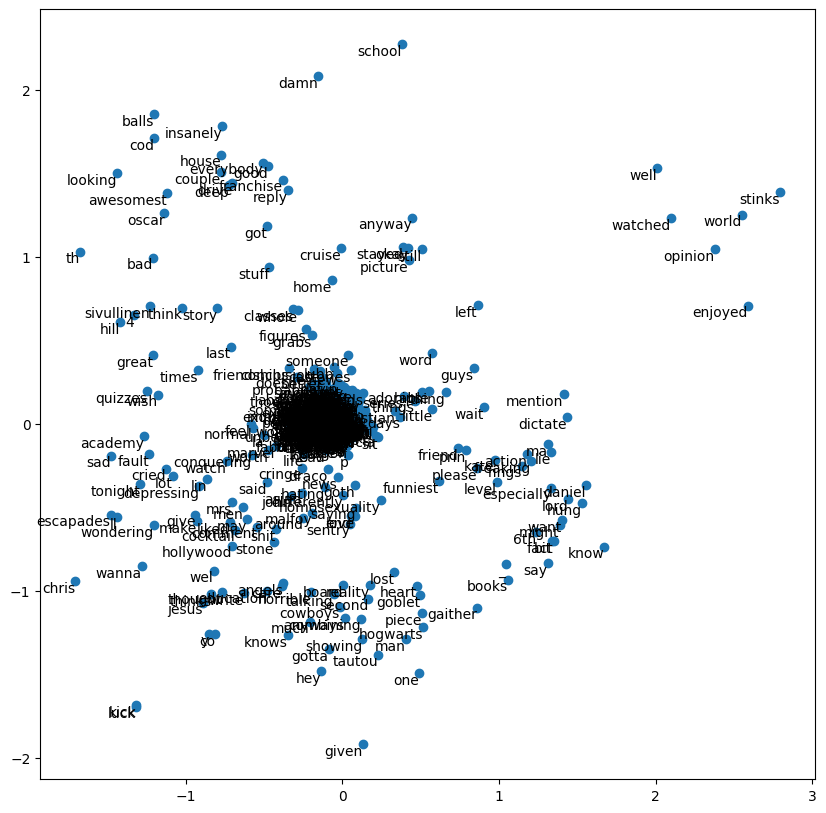

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
plt.scatter(pca_df[:, 0], pca_df[:, 1])
for i,unique_words in enumerate(unique_words):
  plt.annotate(unique_words,horizontalalignment='right',verticalalignment='top',xy=(pca_df[i, 0], pca_df[i, 1]))
plt.show()

In [ ]:
model_text_df=vectorized_data.select(['features','Label'])
model_text_df.show()

+--------------------+-----+
|            features|Label|
+--------------------+-----+
|[0.10361193791031...|  1.0|
|[-0.0237747874576...|  1.0|
|[0.14584937412291...|  1.0|
|[0.14584937412291...|  1.0|
|[0.08936131927475...|  1.0|
|[0.00940775188306...|  1.0|
|[0.12554342462681...|  1.0|
|[0.11257250121395...|  1.0|
|[0.13392436333621...|  1.0|
|[0.13151404028758...|  1.0|
|[0.12545684683654...|  1.0|
|[0.13172388475920...|  1.0|
|[0.11353861967134...|  1.0|
|[0.22401367649436...|  1.0|
|[0.18917513173073...|  1.0|
|[0.14094474073499...|  1.0|
|[0.13764268656571...|  1.0|
|[0.10361193791031...|  1.0|
|[0.15911393300630...|  1.0|
|[0.13035299644495...|  1.0|
+--------------------+-----+
only showing top 20 rows



In [ ]:
from pyspark.ml.feature import VectorAssembler
df_assembler = VectorAssembler(inputCols=['features'],outputCol='features_vec')
model_text_df = df_assembler.transform(model_text_df)
model_text_df.printSchema()

root
 |-- features: vector (nullable = true)
 |-- Label: float (nullable = true)
 |-- features_vec: vector (nullable = true)



In [ ]:
model_text_df.show()

+--------------------+-----+--------------------+
|            features|Label|        features_vec|
+--------------------+-----+--------------------+
|[0.10361193791031...|  1.0|[0.10361193791031...|
|[-0.0237747874576...|  1.0|[-0.0237747874576...|
|[0.14584937412291...|  1.0|[0.14584937412291...|
|[0.14584937412291...|  1.0|[0.14584937412291...|
|[0.08936131927475...|  1.0|[0.08936131927475...|
|[0.00940775188306...|  1.0|[0.00940775188306...|
|[0.12554342462681...|  1.0|[0.12554342462681...|
|[0.11257250121395...|  1.0|[0.11257250121395...|
|[0.13392436333621...|  1.0|[0.13392436333621...|
|[0.13151404028758...|  1.0|[0.13151404028758...|
|[0.12545684683654...|  1.0|[0.12545684683654...|
|[0.13172388475920...|  1.0|[0.13172388475920...|
|[0.11353861967134...|  1.0|[0.11353861967134...|
|[0.22401367649436...|  1.0|[0.22401367649436...|
|[0.18917513173073...|  1.0|[0.18917513173073...|
|[0.14094474073499...|  1.0|[0.14094474073499...|
|[0.13764268656571...|  1.0|[0.13764268656571...|


In [ ]:
from pyspark.ml.classification import LogisticRegression
training_df,test_df=model_text_df.randomSplit([0.75,0.25])

In [ ]:
log_reg=LogisticRegression(featuresCol='features',labelCol='Label').fit(training_df)
results=log_reg.evaluate(test_df).predictions
results.show()

+--------------------+-----+--------------------+--------------------+--------------------+----------+
|            features|Label|        features_vec|       rawPrediction|         probability|prediction|
+--------------------+-----+--------------------+--------------------+--------------------+----------+
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.62981133016984...|       1.0|
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.62981133016984...|       1.0|
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.62981133016984...|       1.0|
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.62981133016984...|       1.0|
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.62981133016984...|       1.0|
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.62981133016984...|       1.0|
|[-0.2573390390191...|  1.0|[-0.2573390390191...|[-17.932216467897...|[1.

In [ ]:
#confusion matrix
true_postives = results[(results.Label == 1) & (results.prediction == 1)].count()
true_negatives = results[(results.Label == 0) & (results.prediction == 0)].count()
false_positives = results[(results.Label == 0) & (results.prediction == 1)].count()
false_negatives = results[(results.Label == 1) & (results.prediction == 0)].count()

In [ ]:
print ('TP=', true_postives)
print('TN =', true_negatives)
print('FP =', false_positives)
print('FN =', false_negatives)

TP= 964
TN = 709
FP = 24
FN = 18


In [ ]:
recall = float(true_postives)/(true_postives + false_negatives)
print(recall)

0.9816700610997964


In [ ]:
precision = float(true_postives) / (true_postives + false_positives)
print(precision)

0.9757085020242915


In [ ]:
accuracy=float((true_postives+true_negatives) /(results.count()))
print(accuracy)

0.9755102040816327
